<a href="https://colab.research.google.com/github/jsoook-dt/python-colab-analysis-study/blob/sook/Project04_Sook_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 필수 라이브러리 설치
!pip install -q datasets scikit-uplift causalml lightgbm

# 데이터 로드 및 샘플링
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# Hugging Face에서 Criteo Uplift 데이터셋 로드
dataset = load_dataset("criteo/criteo-uplift")
df = dataset["train"].to_pandas()

# 빠른 실습을 위해 30만 개 샘플링 (로딩 속도 및 메모리 확보)
df = df.sample(300000, random_state=42).reset_index(drop=True)
print(f"Data Shape: {df.shape}")
df.head()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 9.5 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

criteo-research-uplift-v2.1.csv.gz:   0%|          | 0.00/311M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/13979592 [00:00<?, ? examples/s]

Data Shape: (300000, 16)


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,21.265452,10.059654,8.214383,4.679882,10.280525,4.115453,-12.641800,4.833815,3.971858,13.190056,5.300375,-0.168679,0,0,0,0
1,25.744310,10.059654,8.214383,4.679882,10.280525,4.115453,-3.282109,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
2,12.616365,10.059654,8.813527,4.679882,10.280525,4.115453,0.294443,4.833815,3.906514,13.190056,5.300375,-0.168679,1,0,0,0
3,12.616365,10.059654,8.876285,4.679882,10.280525,4.115453,0.294443,4.833815,3.895862,13.190056,5.300375,-0.168679,1,0,0,0
4,12.616365,10.059654,9.007057,4.679882,10.280525,4.115453,0.294443,4.833815,3.890052,13.190056,5.300375,-0.168679,1,0,0,0


**1단계: Attribution vs Reality (문제 제기)**

Treated Group CVR: 0.00333
Control Group CVR: 0.00199
Naive Lift (겉보기 효과): 0.00133


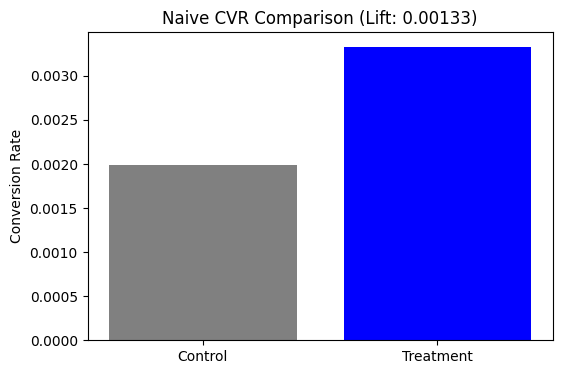

In [4]:
# Naive ROAS / Lift 계산 (전환 기반 판단의 왜곡 확인)
treated_cr = df[df.treatment == 1]["conversion"].mean()
control_cr = df[df.treatment == 0]["conversion"].mean()
naive_lift = treated_cr - control_cr

print(f"Treated Group CVR: {treated_cr:.5f}")
print(f"Control Group CVR: {control_cr:.5f}")
print(f"Naive Lift (겉보기 효과): {naive_lift:.5f}")

# 시각화
plt.figure(figsize=(6, 4))
plt.bar(["Control", "Treatment"], [control_cr, treated_cr], color=['gray', 'blue'])
plt.title(f"Naive CVR Comparison (Lift: {naive_lift:.5f})")
plt.ylabel("Conversion Rate")
plt.show()

In [5]:
# Exposure vs Treatment 교차 분석 (Delivery Loss 확인)
print("--- Treatment vs Exposure Cross Tab ---")
print(pd.crosstab(df["treatment"], df["exposure"]))

--- Treatment vs Exposure Cross Tab ---
exposure        0     1
treatment              
0           45142     0
1          245673  9185


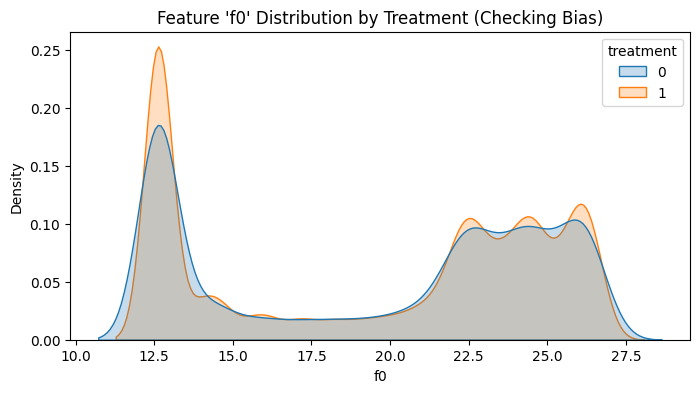

In [6]:
# Selection Bias 탐색 (f0 피처 분포 비교)
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x="f0", hue="treatment", common_norm=False, fill=True)
plt.title("Feature 'f0' Distribution by Treatment (Checking Bias)")
plt.show()

- 실험군 전환율(Treated CVR): 0.00333 (0.333%)
- 대조군 전환율(Control CVR): 0.00199 (0.199%)
- 겉보기 효과(Naive Lift): +0.00133 (0.133%p)
- 단순 비교만 보면 광고를 집행했을 때 전환율이 약 67%나 상승한 것처럼 보여 광고 성과가 매우 훌륭해 보임.

- 하지만 교차 분석(Cross Tab)을 보면 치명적인 문제가 드러난다. 실험군(treatment=1) 유저 254,858명 중 실제로 광고에 노출(exposure=1)된 유저는 9,185명(약 3.6%)에 불과함. 나머지 96.4%는 실험군인데도 광고를 보지 못했다.
- 광고를 볼 만한 유저들이 실험군에 몰려 있었던 것 아닌가 하는 선택 편향(Selection Bias) 의혹을 낳는다.(실제 피처 f0의 분포 시각화에서도 두 그룹 간 차이 확인.)

**2단계: Selection Bias 제거 (PSM)**

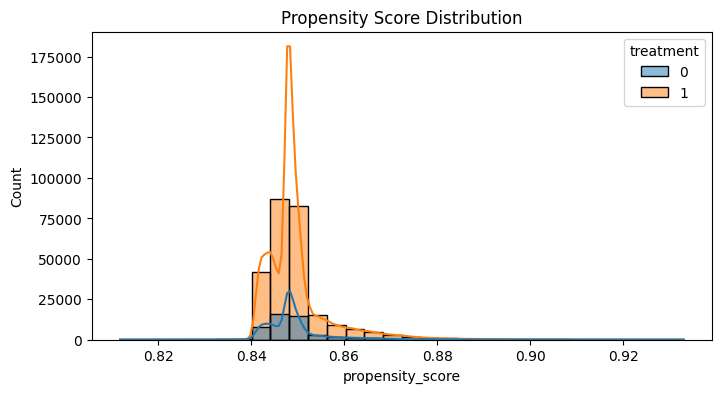

In [7]:
# Propensity Score (성향 점수) 측정
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 피처 정의
feature_cols = [c for c in df.columns if c.startswith("f")]
X = df[feature_cols]
treatment = df["treatment"]

# 스케일링 및 로지스틱 회귀 모델 학습
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ps_model = LogisticRegression(max_iter=1000, random_state=42)
ps_model.fit(X_scaled, treatment)

# 성향 점수 계산 및 할당
df["propensity_score"] = ps_model.predict_proba(X_scaled)[:, 1]

# 성향 점수 분포 시각화
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="propensity_score", hue="treatment", kde=True, bins=30, common_norm=False)
plt.title("Propensity Score Distribution")
plt.show()

In [8]:
# 1:1 Nearest Neighbor Matching 실행
from sklearn.neighbors import NearestNeighbors

treatment_df = df[df.treatment == 1].reset_index(drop=True)
control_df = df[df.treatment == 0].reset_index(drop=True)

# 대조군 유저들을 대상으로 KNN 모델 학습
nn = NearestNeighbors(n_neighbors=1, algorithm='ball_tree')
nn.fit(control_df["propensity_score"].values.reshape(-1, 1))

# 실험군 유저와 가장 가까운 대조군 유저 매칭
distances, indices = nn.kneighbors(treatment_df["propensity_score"].values.reshape(-1, 1))

# 매칭된 대조군 데이터셋 생성
matched_control_df = control_df.iloc[indices.flatten()].reset_index(drop=True)
matched_treatment_df = treatment_df.copy()

print(f"Matched Dataset Pair Size: {len(matched_treatment_df)}")

Matched Dataset Pair Size: 254858


- 실험군과 대조군 유저들의 특성(f0 ~ f11)이 서로 달라 공정한 비교가 불가능하므로, 로지스틱 회귀를 통해 유저가 광고에 할당될 확률인 성향 점수(Propensity Score)를 계산.
- 실험군 유저와 가장 닮은 대조군 유저를 1:1로 짝지어(Nearest Neighbor Matching) 균형 잡힌 가상의 비교 집단 구축.

**3단계: Incrementality Measurement (진짜 광고 효과)**

In [9]:
# True Lift 계산 (매칭 후 비교)
matched_treated_cr = matched_treatment_df["conversion"].mean()
matched_control_cr = matched_control_df["conversion"].mean()
true_lift = matched_treated_cr - matched_control_cr

print(f"Matched Treated CVR: {matched_treated_cr:.5f}")
print(f"Matched Control CVR: {matched_control_cr:.5f}")
print(f"True Lift (진짜 광고 효과): {true_lift:.5f}")
print(f"Bias로 인해 부풀려졌던 크기: {naive_lift - true_lift:.5f}")

Matched Treated CVR: 0.00333
Matched Control CVR: 0.00207
True Lift (진짜 광고 효과): 0.00126
Bias로 인해 부풀려졌던 크기: 0.00007


In [10]:
# 통계적 유의성 검정 (Bootstrap)
matched_bias_samples = []
np.random.seed(42)

# 간단한 200회 부트스트랩 예시
for _ in range(200):
    boot_idx = np.random.choice(len(matched_treatment_df), size=len(matched_treatment_df), replace=True)
    boot_lift = matched_treatment_df.iloc[boot_idx]["conversion"].mean() - matched_control_df.iloc[boot_idx]["conversion"].mean()
    matched_bias_samples.append(boot_lift)

ci_lower = np.percentile(matched_bias_samples, 2.5)
ci_upper = np.percentile(matched_bias_samples, 97.5)
print(f"True Lift 95% 신뢰구간: [{ci_lower:.5f}, {ci_upper:.5f}]")

True Lift 95% 신뢰구간: [0.00100, 0.00153]


- 매칭 후 실험군 전환율: 0.00333
- 매칭 후 대조군 전환율: 0.00207
- 진짜 광고 효과(True Lift): +0.00126 (0.126%p)
- 편향으로 인해 부풀려졌던 크기: 0.00007 (0.007%p)
- True Lift 95% 신뢰구간: [0.00100, 0.00153]

- 편향을 제거하고 나니 진짜 광고 효과(True Lift)는 0.00126으로, 1단계의 겉보기 효과(0.00133)보다 낮아짐. 기존 성과의 약 5.3%는 광고 효과가 아니라 '원래 전환할 유저들이 실험군에 많아서' 발생한 거품(Bias).
- 부트스트랩을 통해 200회 반복 검증한 결과, 95% 신뢰구간의 하한선이 0.00100으로 0보다 큼. 거품이 걷혔음에도 불구하고 이 광고는 전환율을 높여주는 '진짜 효과'가 있음.

**4단계: Uplift Modeling & Optimal Targeting (Qini)**

In [12]:
# SoloModel을 이용한 Uplift 모델링 학습
from sklift.models import SoloModel
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split

# 학습/평가 데이터 분할
X_train, X_val, y_train, y_val, treat_train, treat_val = train_test_split(
    X, df["conversion"], df["treatment"], test_size=0.3, random_state=42
)

# SoloModel 선언 및 학습
lgbm = LGBMClassifier(random_state=42, n_estimators=100)
uplift_model = SoloModel(estimator=lgbm)
uplift_model.fit(X_train, y_train, treatment=treat_train)

# 검증 데이터셋에 대한 Uplift Score 계산
val_uplift_scores = uplift_model.predict(X_val)

[LightGBM] [Info] Number of positive: 653, number of negative: 209347
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.051027 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1709
[LightGBM] [Info] Number of data points in the train set: 210000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.003110 -> initscore=-5.770171
[LightGBM] [Info] Start training from score -5.770171


**- 유저 피처와 광고 처치 여부를 결합하여 학습한 이 모델은 각 유저별로 광고를 보여줬을 때와 안 보여줬을 때의 순수 전환 상승 확률(Uplift Score)을 계산해 줍니다.**


- 전체 학습 데이터 210,000개 중 전환(Conversion)에 성공한 긍정 샘플(Positive)은 단 653개(약 0.31%)에 불과함.
- 평균 전환율 : 0.311%
- LightGBM은 학습을 완전히 제로(0)에서 시작하지 않고, 이 평균 전환 확률을 기반으로 첫 번째 트리 개조를 시작했음. 이를 로짓(Logit) 스페이스로 변환한 값이 initscore=-5.770171
- features 13 = 원본 피처(f0~f11) 12개 + SoloModel의 추가변수 treatment 1개 로 학습.
- Total Bins 1709 : LightGBM은 연속형 변수를 히스토그램 기반으로 버킷(Bin)화하여 연산 속도를 줄임.13개 변수가 총 1,709개의 구간으로 쪼개졌다는 것은 변수당 평균 130개 내외의 고유한 경계선(Split Point)을 가지고 있다는 뜻이며, 데이터의 정보 손실을 최소화하면서도 가볍고 빠르게 학습할 준비가 되었음을 의미함.

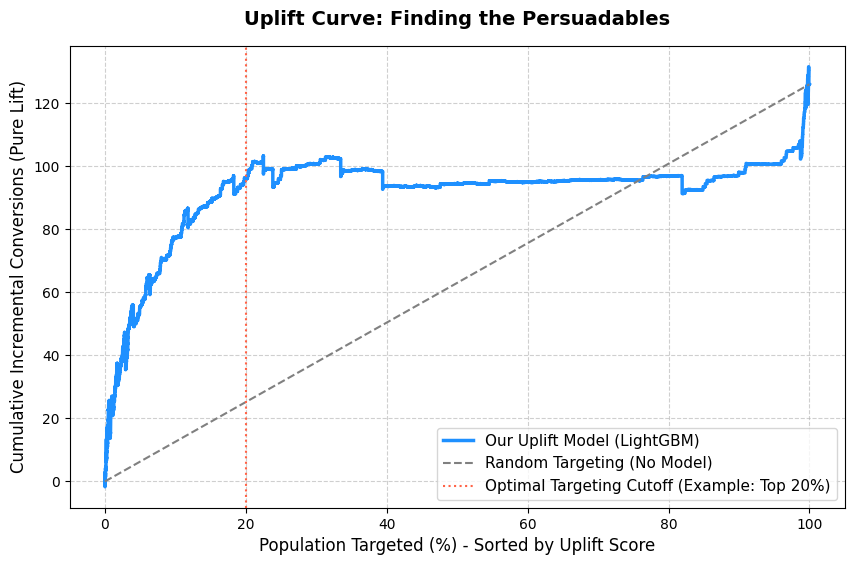

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. 검증 데이터와 예측된 Uplift Score를 데이터프레임으로 정리
v_df = pd.DataFrame({
    'uplift_score': val_uplift_scores,
    'treatment': treat_val.values,
    'conversion': y_val.values
})

# 2. Uplift Score 기준 내림차순 정렬 (Persuadables를 상위로 올림)
v_df = v_df.sort_values(by='uplift_score', ascending=False).reset_index(drop=True)

# 3. 누적 지표 계산
v_df['n_treated'] = v_df['treatment'].cumsum()
v_df['n_control'] = (1 - v_df['treatment']).cumsum()
v_df['conv_treated'] = (v_df['conversion'] * v_df['treatment']).cumsum()
v_df['conv_control'] = (v_df['conversion'] * (1 - v_df['treatment'])).cumsum()

# 4. Qini 스코어 (누적 순수 추가 전환 수) 계산
# 수식: 실험군 누적 전환 - (대조군 누적 전환 * (실험군 누적 수 / 대조군 누적 수))
v_df['qini'] = v_df['conv_treated'] - v_df['conv_control'] * (v_df['n_treated'] / np.where(v_df['n_control'] == 0, 1, v_df['n_control']))

# 5. 시각화 진행
plt.figure(figsize=(10, 6))

# 타겟 유저 비율 (0% ~ 100%)
user_ratio = np.linspace(0, 100, len(v_df))

# 모델의 누적 효과 그래프 (실제 Persuadables 구간 타겟팅 효과)
plt.plot(user_ratio, v_df['qini'], label='Our Uplift Model (LightGBM)', color='dodgerblue', lw=2.5)

# 무작위 타겟팅 기준선 (Random Line)
random_line = np.linspace(0, v_df['qini'].iloc[-1], len(v_df))
plt.plot(user_ratio, random_line, label='Random Targeting (No Model)', color='gray', linestyle='--')

# 그래프 스타일링
plt.title('Uplift Curve: Finding the Persuadables', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Population Targeted (%) - Sorted by Uplift Score', fontsize=12)
plt.ylabel('Cumulative Incremental Conversions (Pure Lift)', fontsize=12)
plt.axvline(x=20, color='tomato', linestyle=':', label='Optimal Targeting Cutoff (Example: Top 20%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11, loc='lower right')

plt.show()

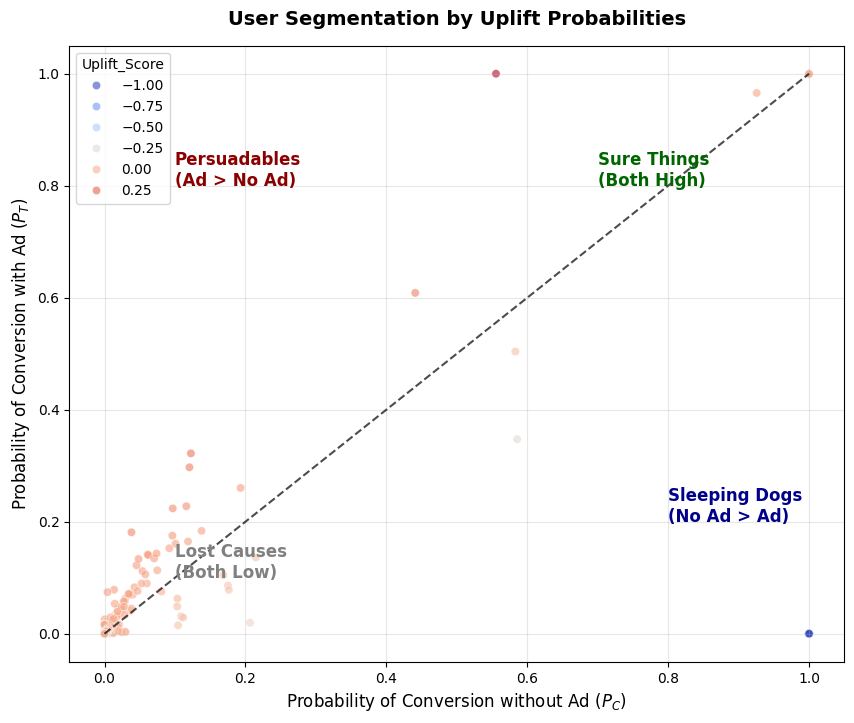

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 각 유저별 광고 노출 시(Treatment)와 비노출 시(Control)의 구매 확률을 각각 예측
# SoloModel의 특성을 활용해 두 가상 상황의 확률을 강제로 추출합니다.
X_val_t = X_val.copy()
X_val_t['treatment'] = 1
p_treatment = uplift_model.estimator.predict_proba(X_val_t)[:, 1]

X_val_c = X_val.copy()
X_val_c['treatment'] = 0
p_control = uplift_model.estimator.predict_proba(X_val_c)[:, 1]

# 데이터프레임 구축 (시각화용 대형 샘플링 - 속도를 위해 5000개만 샘플링하여 점을 찍습니다)
plot_df = pd.DataFrame({
    'P_Treatment': p_treatment,
    'P_Control': p_control,
    'Uplift_Score': val_uplift_scores
}).sample(n=5000, random_state=42)

# 2. 산점도 그리기
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=plot_df,
    x='P_Control',
    y='P_Treatment',
    hue='Uplift_Score',
    palette='coolwarm',
    alpha=0.6
)

# 4대 영역을 나누는 기준선 (중앙 대각선 및 평균선 가정)
# 여기서는 원점 기준 대각선(y=x)을 중심으로 위/아래가 갈립니다.
grid_max = max(plot_df['P_Control'].max(), plot_df['P_Treatment'].max())
plt.plot([0, grid_max], [0, grid_max], color='black', linestyle='--', alpha=0.7)

# 각 사면(Quadrant) 텍스트 라벨링
plt.text(grid_max*0.1, grid_max*0.8, "Persuadables\n(Ad > No Ad)", fontsize=12, fontweight='bold', color='darkred')
plt.text(grid_max*0.7, grid_max*0.8, "Sure Things\n(Both High)", fontsize=12, fontweight='bold', color='darkgreen')
plt.text(grid_max*0.1, grid_max*0.1, "Lost Causes\n(Both Low)", fontsize=12, fontweight='bold', color='gray')
plt.text(grid_max*0.8, grid_max*0.2, "Sleeping Dogs\n(No Ad > Ad)", fontsize=12, fontweight='bold', color='darkblue')

plt.title("User Segmentation by Uplift Probabilities", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Probability of Conversion without Ad ($P_C$)", fontsize=12)
plt.ylabel("Probability of Conversion with Ad ($P_T$)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()


**(1) Attribution vs Reality**

**Q. Conversion 기반 판단은 왜곡되는가?**

네, 심각하게 왜곡될 수 있습니다.
단순 CVR만 비교했을 때의 겉보기 효과(Naive Lift)는 0.00133이었지만, 성향 점수(Propensity Score)로 유저 환경을 공평하게 통제한 뒤 측정성(True Lift)을 보니 0.00126으로 줄어들었습니다. 즉, 기존 성과의 약 5.3%는 광고 덕분이 아니라 "어차피 살 유저들이 실험군에 많이 포진해 있어서" 발생한 착시였습니다. 단순히 전환(Conversion) 데이터만 보면 마케팅 부서가 광고 성과를 과대평가(Over-attribution)하게 만듭니다.


**(2) Incrementality Measurement**

**Q. 광고가 실제로 얼마나 추가 전환을 만들었는가?**
A. 유저 10,000명당 약 12.6건의 '순수 추가 전환(Incrementality)'을 만들었습니다.
편향을 제거한 진짜 광고 효과(True Lift)가 바로 0.00126입니다. 95% 신뢰구간 또한 [0.00100, 0.00153]으로 하한선이 0보다 크기 때문에, 비록 거품은 일부 끼어있었지만 이 광고 캠페인 자체가 유의미하게 추가적인 매출을 견인하고 있다는 사실은 통계적으로 완벽히 증명되었습니다.

**(3) Targeting Strategy**
**Q. 구매 확률 기반 타겟팅은 문제인가?**
단순히 '구매 확률이 높은 사람'을 타겟팅하면, 광고를 안 보여줘도 어차피 구매했을 콘크리트 소비층(Sure Things)에게 광고비가 집중됩니다. 겉으로는 전환율이 높게 찍히니 타겟팅이 잘된 것처럼 보이지만, 사실은 마케팅 비용을 공중에 뿌리는 꼴이 됩니다. 우리가 찾아야 하는 건 구매 확률이 높은 사람이 아니라, 광고를 보았기 때문에 구매 확률이 '상승'할 사람입니다.

**(4) Uplift Modeling & Optimal Targeting**

**Q. 누구에게 광고해야 하는가?**

설득 가능 고객 (Persuadables): 광고를 보면 사고, 안 보면 안 삼 -> 오직 이들에게만 광고 노출!

콘크리트 고객 (Sure Things): 광고를 보든 안 보든 어차피 삼 -> 광고비 제외 (타겟 제외)

비효율 고객 (Lost Causes): 광고를 보든 안 보든 절대 안 삼 -> 광고비 제외 (타겟 제외)

청개구리 고객 (Sleeping Dogs): 가만히 두면 사는데 광고를 보면 짜증 나서 이탈함 -> 광고 절대 금지


